   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compression-ratio hor

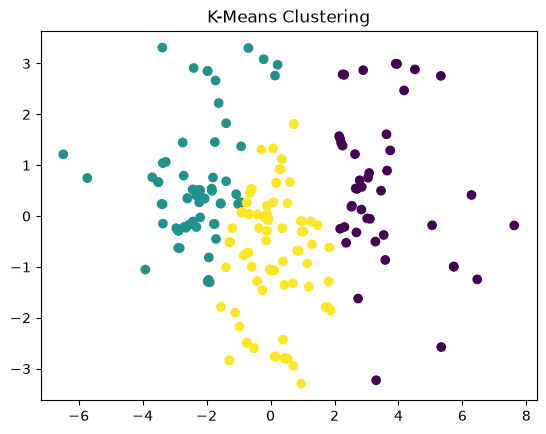

  normalized-losses  Cluster  NLP_Cluster
0                 ?        2            0
1                 ?        2            0
2                 ?        2            0
3               164        2            0
4               164        2            0
Completed!


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4886/2649277588.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes("object").columns[0]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("automotive_data.csv")
print(df.head())

# K-Means
num = df.select_dtypes("number").columns
X = df[num].fillna(df[num].median())
X = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X)

# Plot clusters
p = PCA(2).fit_transform(X)
plt.scatter(p[:,0], p[:,1], c=df["Cluster"])
plt.title("K-Means Clustering")
plt.show()

# NLP
text_col = df.select_dtypes("object").columns[0]
T = TfidfVectorizer(stop_words="english").fit_transform(
    df[text_col].fillna("")
)

nlp = KMeans(n_clusters=3, random_state=42, n_init=10)
df["NLP_Cluster"] = nlp.fit_predict(T)

print(df[[text_col, "Cluster", "NLP_Cluster"]].head())

# Save
df.to_csv("automotive_clustered.csv", index=False)
print("Completed!")